In [1]:
import json
import subprocess
import sys
import os
import copy
import matplotlib.pyplot as plt
import numpy as np
import random

sys.path.append('../../../framework/PythonTools')

from Spacepoint import Spacepoint
from Solution import Solution
from ParticleInitial import ParticleInitial
from MathFunctions import *
from TestsCommon import *

`erase_test_list()` is defined in `TestsCommon.py` and is here not to run all tests when you are working on a single test.

If you want to run all tests, uncomment `erase_test_list()`, run all, run `runTests.py` `/helix/repo` in container, and then run all again.

In [ ]:
# def erase_test_list():
#     pass

In [2]:
base_dir = "/helix/repo/test_results"
base_dir_relative = "../../../test_results"
data_dir = "/helix/repo/data/odd_output_ttbar_PU200_100"
data_dir_relative = "../../../data/odd_output_ttbar_PU200_100"

generic_test_params = SolverTestParams()
generic_test_params.testType = ""
generic_test_params.eventId = 0
generic_test_params.multipleEventIds = []
generic_test_params.numRuns = 0
generic_test_params.inputSpacepointsFile = data_dir + "/spacepoints.root"
generic_test_params.inputParticlesInitialFile = data_dir + "/particles_initial.root"
generic_test_params.inputSpacepointsGenerationParamsFile = ""
generic_test_params.outputResultsFile = ""
generic_test_params.maxAbsXy = 1100.0
generic_test_params.maxAbsZ = 3100.0
generic_test_params.minZAngle = 0.0
generic_test_params.maxZAngle = 2 * math.pi
generic_test_params.minXAngle = math.pi * 5 / 256
generic_test_params.maxXAngle = math.pi * 251 / 256
generic_test_params.poleRegionAngle = math.pi * 5 / 256
generic_test_params.interactionRegionMin = -200.0
generic_test_params.interactionRegionMax = 200.0
generic_test_params.zAngleMargin = math.pi / 32
generic_test_params.xAngleMargin = math.pi / 128
generic_test_params.numZRanges = 32
generic_test_params.numXRanges = 48
generic_test_params.filterOutCenterR = 140.0
generic_test_params.filterOutCenterZ = 550.0
generic_test_params.hitsThresholds = [7 for _ in range(generic_test_params.numXRanges)]
generic_test_params.linesCrossingsThresholds = [3 for _ in range(generic_test_params.numXRanges)]

In [3]:
def write_spacepoints_generation_params(spacepoints_generation_params, file_path):
    with open(file_path, "w") as f:
        for param in spacepoints_generation_params:
            f.write(f"{param[0]},{param[1]},{param[2]}\n")

def generate_spacepoints_generation_params(particles_initial_all, particle_to_params_func, envent_id=None):
    if envent_id is not None:
        particles_filtered = [p for p in particles_initial_all if p.event_id == envent_id]
    else:
        particles_filtered = particles_initial_all

    spacepoints_generation_params = []
    particle_to_generation_params_map = {}
    for i in range(len(particles_filtered)):
        spacepoints_generation_params.append(particle_to_params_func(particles_filtered[i]))
        particle_to_generation_params_map[particles_filtered[i].particle_id] = spacepoints_generation_params[i]

    return spacepoints_generation_params, particle_to_generation_params_map

In [4]:
def map_solutions_to_particles_rppi(particles, particle_to_generation_params_map, solutions):
    for solution in solutions:
        z_angle = angle_wrap_2pi(solution.phi - math.pi / 2)
        solution.z_angle = z_angle

    particles_by_id = {particle.particle_id: particle for particle in particles}
    
    particle_to_solutions_map = {}
    for solution in solutions:
        if solution.particle_id not in particles_by_id:
            continue

        r = particle_to_generation_params_map[solution.particle_id][0]
        if r < 0.95 * solution.r or r > 1.05 * solution.r:
            continue

        q = 1 if particle_to_generation_params_map[solution.particle_id][1] else -1
        if q * solution.q < 0:
            continue

        particle = particles_by_id[solution.particle_id]
        x_angle, z_angle = direction_to_angles(particle.direction_x, particle.direction_y, particle.direction_z)

        if solution.z_angle < z_angle - math.pi / 64 or solution.z_angle > z_angle + math.pi / 64:
            continue

        if solution.x_angle_min > x_angle + math.pi / 64 or solution.x_angle_max < x_angle - math.pi / 64:
            continue

        if solution.particle_id not in particle_to_solutions_map:
            particle_to_solutions_map[solution.particle_id] = []

        particle_to_solutions_map[solution.particle_id].append(solution)
    return particle_to_solutions_map

def map_solutions_to_x_angle_ranges(solutions):
    solutions_by_x_angle_range = {}
    for solution in solutions:
        x_angle_range = (solution.x_angle_min, solution.x_angle_max)
        if x_angle_range not in solutions_by_x_angle_range:
            solutions_by_x_angle_range[x_angle_range] = []
        solutions_by_x_angle_range[x_angle_range].append(solution)
    return solutions_by_x_angle_range

def map_solutions_to_z_and_x_angle_ranges(solutions, solutions_by_x_angle_range, z_angle_ranges):
    solutions_by_x_and_z_angle_range = {}
    for x_angle_range in solutions_by_x_angle_range:
        for z_angle_range in z_angle_ranges:
            xz_ranges = (x_angle_range, z_angle_range)
            for solution in solutions_by_x_angle_range[x_angle_range]:
                if solution.z_angle >= z_angle_range[0] and solution.z_angle <= z_angle_range[1]:
                    if xz_ranges not in solutions_by_x_and_z_angle_range:
                        solutions_by_x_and_z_angle_range[xz_ranges] = []

                    solutions_by_x_and_z_angle_range[xz_ranges].append(solution)
    return solutions_by_x_and_z_angle_range

def map_solutions_to_particles_pi(particles, particle_to_generation_params_map, solutions):
    for solution in solutions:
        z_angle = angle_wrap_2pi(solution.phi - math.pi / 2)
        solution.z_angle = z_angle

    solutions_by_x_angle_range = map_solutions_to_x_angle_ranges(solutions)
    z_angle_ranges = [(i / 16 * math.pi, (i + 1) / 16 * math.pi) for i in range(32)]
    solutions_by_x_and_z_angle_range = map_solutions_to_z_and_x_angle_ranges(solutions, solutions_by_x_angle_range, z_angle_ranges)

    x_angle_ranges_sorted = sorted(solutions_by_x_angle_range.keys())
    z_angle_ranges_sorted = sorted(z_angle_ranges)

    particle_to_solutions_map = {}
    for particle in particles:
        x_angle, z_angle = direction_to_angles(particle.direction_x, particle.direction_y, particle.direction_z)

        x_angle_ranges_to_check = []
        for i, x_angle_range in enumerate(x_angle_ranges_sorted):
            if x_angle >= x_angle_range[0] and x_angle <= x_angle_range[1]:
                x_angle_ranges_to_check = x_angle_ranges_sorted[max(0, i-2):min(len(x_angle_ranges_sorted), i+3)]
                break

        z_angle_ranges_to_check = []
        for i, z_angle_range in enumerate(z_angle_ranges_sorted):
            if z_angle >= z_angle_range[0] and z_angle <= z_angle_range[1]:
                z_angle_ranges_to_check = z_angle_ranges_sorted[max(0, i-2):min(len(z_angle_ranges_sorted), i+3)]
                break

        angle_range_pairs_to_check = []
        for xar in x_angle_ranges_to_check:
            for zar in z_angle_ranges_to_check:
                angle_range_pairs_to_check.append((xar, zar))

        for angle_range_pair in angle_range_pairs_to_check:
            if angle_range_pair not in solutions_by_x_and_z_angle_range:
                continue

            for solution in solutions_by_x_and_z_angle_range[angle_range_pair]:
                r = particle_to_generation_params_map[particle.particle_id][0]
                if r < 0.95 * solution.r or r > 1.05 * solution.r:
                    continue

                q = -1 if particle_to_generation_params_map[particle.particle_id][1] else 1
                if q * solution.q < 0:
                    continue

                if z_angle < solution.z_angle - math.pi / 64 or z_angle > solution.z_angle + math.pi / 64:
                    continue

                if solution.x_angle_min > x_angle + math.pi / 64 or solution.x_angle_max < x_angle - math.pi / 64:
                    continue

                if particle.particle_id not in particle_to_solutions_map:
                    particle_to_solutions_map[particle.particle_id] = []

                particle_to_solutions_map[particle.particle_id].append(solution)

    return particle_to_solutions_map

def map_solutions_to_particles_s(particles, solutions):
    for solution in solutions:
        z_angle = angle_wrap_2pi(solution.phi - math.pi / 2)
        solution.z_angle = z_angle

    solutions_by_x_angle_range = map_solutions_to_x_angle_ranges(solutions)
    z_angle_ranges = [(i / 16 * math.pi, (i + 1) / 16 * math.pi) for i in range(32)]
    solutions_by_x_and_z_angle_range = map_solutions_to_z_and_x_angle_ranges(solutions, solutions_by_x_angle_range, z_angle_ranges)

    x_angle_ranges_sorted = sorted(solutions_by_x_angle_range.keys())
    z_angle_ranges_sorted = sorted(z_angle_ranges)

    particle_to_solutions_map = {}
    for particle in particles:
        x_angle, z_angle = direction_to_angles(particle.direction_x, particle.direction_y, particle.direction_z)

        x_angle_ranges_to_check = []
        for i, x_angle_range in enumerate(x_angle_ranges_sorted):
            if x_angle >= x_angle_range[0] and x_angle <= x_angle_range[1]:
                x_angle_ranges_to_check = x_angle_ranges_sorted[max(0, i-2):min(len(x_angle_ranges_sorted), i+3)]
                break

        z_angle_ranges_to_check = []
        for i, z_angle_range in enumerate(z_angle_ranges_sorted):
            if z_angle >= z_angle_range[0] and z_angle <= z_angle_range[1]:
                z_angle_ranges_to_check = z_angle_ranges_sorted[max(0, i-2):min(len(z_angle_ranges_sorted), i+3)]
                break

        angle_range_pairs_to_check = []
        for xar in x_angle_ranges_to_check:
            for zar in z_angle_ranges_to_check:
                angle_range_pairs_to_check.append((xar, zar))

        for angle_range_pair in angle_range_pairs_to_check:
            if angle_range_pair not in solutions_by_x_and_z_angle_range:
                continue

            for solution in solutions_by_x_and_z_angle_range[angle_range_pair]:
                r = 1000 * particle.pt / 0.6
                if r < 0.95 * solution.r or r > 1.05 * solution.r:
                    continue

                if solution.q * particle.q < 0:
                    continue

                if z_angle < solution.z_angle - math.pi / 64 or z_angle > solution.z_angle + math.pi / 64:
                    continue

                if solution.x_angle_min > x_angle + math.pi / 64 or solution.x_angle_max < x_angle - math.pi / 64:
                    continue

                if particle.particle_id not in particle_to_solutions_map:
                    particle_to_solutions_map[particle.particle_id] = []

                particle_to_solutions_map[particle.particle_id].append(solution)

    return particle_to_solutions_map

In [5]:
def filter_particles_by_x_angle_and_pt(particles, min_x_angle, max_x_angle, min_pt):
    particles_filtered = [p for p in particles if p.pt > min_pt]
    x_angles = [direction_to_angles(p.direction_x, p.direction_y, p.direction_z)[0] for p in particles_filtered]
    return [particles_filtered[i] for i in range(len(particles_filtered)) if x_angles[i] >= min_x_angle and x_angles[i] < max_x_angle]

def filter_particles_by_x_angle_and_event_id(particles, event_id, min_x_angle, max_x_angle):
    particles_filtered = [p for p in particles if p.event_id == event_id]
    x_angles = [direction_to_angles(p.direction_x, p.direction_y, p.direction_z)[0] for p in particles_filtered]
    return [particles_filtered[i] for i in range(len(particles_filtered)) if x_angles[i] >= min_x_angle and x_angles[i] < max_x_angle]

def filter_particles_by_x_angle_event_id_pt_and_q(particles, event_id, min_x_angle, max_x_angle, min_pt, q_negative=None):
    particles_filtered = filter_particles_by_x_angle_and_event_id(particles, event_id, min_x_angle, max_x_angle)
    return [p for p in particles_filtered if p.pt > min_pt and (q_negative is None or (q_negative == "positive" and p.q > 0) or (q_negative == "negative" and p.q < 0))]

def get_accuracy_by_criteria(particles, particle_to_solutions_map, bins, criteria_func, include_counts=False):
    sum_per_bin = [0] * len(bins)
    count_per_bin = [0] * len(bins)
    for i in range(len(particles)):
        has_solution = particle_to_solutions_map.get(particles[i].particle_id) is not None
        for j in range(len(bins)):
            if not criteria_func(particles[i], bins[j]):
                continue

            sum_per_bin[j] += 1 if has_solution else 0
            count_per_bin[j] += 1

    average_per_bin = [sum_per_bin[i] / count_per_bin[i] if count_per_bin[i] > 0 else 0 for i in range(len(bins))]
    if include_counts:
        return bins, average_per_bin, count_per_bin, sum_per_bin
    else:
        return bins, average_per_bin

def get_accuracy_by_z_angle(particles, particle_to_solutions_map, test_params, include_counts=False):
    def criteria_func(p, bin):
        x_angle, z_angle = direction_to_angles(p.direction_x, p.direction_y, p.direction_z)
        return z_angle >= bin[0] and z_angle < bin[1] and x_angle >= test_params.minXAngle and x_angle < test_params.maxXAngle

    bins = uniform_range_split(test_params.numZRanges, test_params.minZAngle, test_params.maxZAngle, test_params.zAngleMargin)
    return get_accuracy_by_criteria(particles, particle_to_solutions_map, bins, criteria_func, include_counts)

def get_accuracy_by_x_angle(particles, particle_to_solutions_map, test_params, include_counts=False):
    def criteria_func(p, bin):
        x_angle = direction_to_angles(p.direction_x, p.direction_y, p.direction_z)[0]
        return x_angle >= bin[0] and x_angle < bin[1]
    
    bins = uniform_range_split(test_params.numXRanges, test_params.minXAngle, test_params.maxXAngle, test_params.xAngleMargin)
    return get_accuracy_by_criteria(particles, particle_to_solutions_map, bins, criteria_func, include_counts)

def get_accuracy_by_pt(particles, particle_to_solutions_map, min_pt=None, max_pt=None, num_bins=None, bins=None, include_counts=False):
    def criteria_func(p, bin):
        return p.pt >= bin[0] and p.pt < bin[1]
    
    if bins is None:
        bins = uniform_range_split(num_bins, min_pt, max_pt, 0)
    return get_accuracy_by_criteria(particles, particle_to_solutions_map, bins, criteria_func, include_counts)

def get_accuracy(particles, particle_to_solutions_map, test_params):
    bins = [None]
    return get_accuracy_by_criteria(particles, particle_to_solutions_map, bins, lambda p, bin: True)[1]

In [6]:
def get_stats_for_all_events(particles_initial, solutions_all, test_params, q_negative=None):
    x_angle_bins_all = None
    x_angle_counts_all = []
    x_angle_sums_all = []

    pt_bins_all = None
    pt_counts_all = []
    pt_sums_all = []

    for event_id in range(20):
        particles_filtered = filter_particles_by_x_angle_event_id_pt_and_q(particles_initial, event_id, test_params.minXAngle, test_params.maxXAngle, min_pt=1, q_negative=q_negative)
        solutions = [s for s in solutions_all if s.event_id == event_id]

        particle_to_solutions_map = map_solutions_to_particles_s(particles_filtered, solutions)
        x_angle_bins, x_angle_accuracies, x_angle_counts, x_angle_sums = get_accuracy_by_x_angle(particles_filtered, particle_to_solutions_map, test_params, include_counts=True)

        if x_angle_bins_all is None:
            x_angle_bins_all = x_angle_bins
            x_angle_counts_all = x_angle_counts
            x_angle_sums_all = x_angle_sums

        for j in range(len(x_angle_bins)):
            x_angle_counts_all[j] += x_angle_counts[j]
            x_angle_sums_all[j] += x_angle_sums[j]

        pt_bins = uniform_range_split(16, 1, 17, 0) + uniform_range_split(16, 17, 81, 0)
        pt_bins, pt_accuracies, pt_counts, pt_sums = get_accuracy_by_pt(particles_filtered, particle_to_solutions_map, bins=pt_bins, include_counts=True)

        if pt_bins_all is None:
            pt_bins_all = pt_bins
            pt_counts_all = pt_counts
            pt_sums_all = pt_sums

        for j in range(len(pt_bins)):
            pt_counts_all[j] += pt_counts[j]
            pt_sums_all[j] += pt_sums[j]


    x_angle_accuracies_all = [x_angle_sums_all[i] / x_angle_counts_all[i] if x_angle_counts_all[i] > 0 else 0 for i in range(len(x_angle_bins_all))]
    pt_accuracies_all = [pt_sums_all[i] / pt_counts_all[i] if pt_counts_all[i] > 0 else 0 for i in range(len(pt_bins_all))]

    for solution in solutions_all:
        z_angle = angle_wrap_2pi(solution.phi - math.pi / 2)
        solution.z_angle = z_angle

    solutions_by_x_angle_range = map_solutions_to_x_angle_ranges(solutions_all)

    solutions_count_by_x_angle_range = {}
    for i in solutions_by_x_angle_range:
        solutions_count_by_x_angle_range[i] = len(solutions_by_x_angle_range[i])

    return {
        "x_angle_bins_all": x_angle_bins_all,
        "x_angle_counts_all": x_angle_counts_all,
        "x_angle_sums_all": x_angle_sums_all,
        "x_angle_accuracies_all": x_angle_accuracies_all,
        "pt_bins_all": pt_bins_all,
        "pt_counts_all": pt_counts_all,
        "pt_sums_all": pt_sums_all,
        "pt_accuracies_all": pt_accuracies_all,
        "solutions_count_by_x_angle_range": solutions_count_by_x_angle_range,
    }

In [7]:
particles_initial_all = ParticleInitial.read_from_csv(data_dir_relative + "/particles_initial.csv")
spacepoints = Spacepoint.read_from_csv(data_dir_relative + "/spacepoints.csv")

# Filter out particles that do not originate from the interaction region
particles_initial = [p for p in particles_initial_all if math.sqrt(p.vx ** 2 + p.vy ** 2) < 0.1 and abs(p.vz) < 200]

# Run per particle initial

# RPPI - Accuracy for xAngle and zAngle ranges

In [ ]:
erase_test_list()

In [ ]:
test_params = copy.copy(generic_test_params)
test_params.testType = "RunPerParticleInitial"
test_params.inputSpacepointsGenerationParamsFile = base_dir + "/quality_tests/rppi_accuracy_by_region/inputSpacepointsGenerationParams.csv"
test_params.outputResultsFile = base_dir + "/quality_tests/rppi_accuracy_by_region/results.csv"
test_params.minXAngle = math.pi * 5 / 256
test_params.maxXAngle = math.pi * 251 / 256
test_params.poleRegionAngle = math.pi * 5 / 256
test_params.zAngleMargin = math.pi / 32
test_params.xAngleMargin = math.pi / 64
test_params.numZRanges = 64
test_params.numXRanges = 64
test_params.hitsThresholds = [7 for _ in range(test_params.numXRanges)]
test_params.linesCrossingsThresholds = [3 for _ in range(test_params.numXRanges)]

write_config(test_params, base_dir_relative + "/quality_tests/rppi_accuracy_by_region", base_dir_relative + "/quality_tests/rppi_accuracy_by_region/config.json")
add_test_to_list(base_dir + "/quality_tests/rppi_accuracy_by_region/config.json")

random.seed(42)
def particle_to_params_func(particle):
    r = random.randint(1666, 20000)
    counter_clock_wise = random.choice([True, False])
    num_points = 10
    return [r, counter_clock_wise, num_points]

spacepoints_generation_params, particle_to_generation_params_map = generate_spacepoints_generation_params(particles_initial_all, particle_to_params_func, test_params.eventId)
write_spacepoints_generation_params(spacepoints_generation_params, base_dir_relative + "/quality_tests/rppi_accuracy_by_region/inputSpacepointsGenerationParams.csv")

r = 1666 is equivalent to pt = 1 GeV/c

In [ ]:
particles_filtered = [p for p in particles_initial if p.event_id == test_params.eventId]
solutions = Solution.read_from_csv(base_dir_relative + "/quality_tests/rppi_accuracy_by_region/results.csv")
particle_to_solutions_map = map_solutions_to_particles_rppi(particles_filtered, particle_to_generation_params_map, solutions)
print(f"Found {len(particle_to_solutions_map)}/{len(particles_filtered)} particles")

In [ ]:
accuracy_data = get_accuracy_by_x_angle(particles_filtered, particle_to_solutions_map, test_params, include_counts=True)
draw_errorbar_chart(accuracy_data, "$x_{angle}$ efficiency, CI 95%", figure_size=(12, 2), draw_values=False)

In [ ]:
particles_filtered = filter_particles_by_x_angle_and_event_id(particles_initial, test_params.eventId, test_params.minXAngle, test_params.maxXAngle)
print(f"Number of particles: {len(particles_filtered)}")
accuracy_data = get_accuracy_by_z_angle(particles_filtered, particle_to_solutions_map, test_params, include_counts=True)
draw_errorbar_chart(accuracy_data, "$z_{angle}$ efficiency, CI 95%", figure_size=(12, 2), draw_values=False)

# RPPI accuracy by z-angle margin

In [ ]:
erase_test_list()

In [ ]:
test_params = copy.copy(generic_test_params)
test_params.testType = "RunPerParticleInitial"
test_params.inputSpacepointsGenerationParamsFile = base_dir + "/quality_tests/rppi_accuracy_by_zangle_margin/inputSpacepointsGenerationParams.csv"
test_params.outputResultsFile = base_dir + "/quality_tests/rppi_accuracy_by_zangle_margin/results.csv"
test_params.xAngleMargin = math.pi / 64
test_params.numZRanges = 64
test_params.numXRanges = 64
test_params.hitsThresholds = [7 for _ in range(test_params.numXRanges)]
test_params.linesCrossingsThresholds = [3 for _ in range(test_params.numXRanges)]

random.seed(42)
def particle_to_params_func(particle):
    r = 1666
    counter_clock_wise = True
    num_points = 10
    return [r, counter_clock_wise, num_points]

spacepoints_generation_params, particle_to_generation_params_map = generate_spacepoints_generation_params(particles_initial_all, particle_to_params_func, test_params.eventId)
write_spacepoints_generation_params(spacepoints_generation_params, base_dir_relative + "/quality_tests/rppi_accuracy_by_zangle_margin/inputSpacepointsGenerationParams.csv")

margins = [math.pi * i / 32 / 16 for i in range(32)]
margins[0] = 1e-6
for i, margin in enumerate(margins):
    test_params.zAngleMargin = margin
    test_params.outputResultsFile = base_dir + f"/quality_tests/rppi_accuracy_by_zangle_margin/results_{i}.csv"
    write_config(test_params, base_dir_relative + "/quality_tests/rppi_accuracy_by_zangle_margin", base_dir_relative + f"/quality_tests/rppi_accuracy_by_zangle_margin/config_{i}.json")
    add_test_to_list(base_dir + f"/quality_tests/rppi_accuracy_by_zangle_margin/config_{i}.json")

In [ ]:
particles_filtered = filter_particles_by_x_angle_and_event_id(particles_initial, test_params.eventId, test_params.minXAngle, test_params.maxXAngle)

margin_to_accuracy_map = {}
for i, margin in enumerate(margins):
    solutions = Solution.read_from_csv(base_dir_relative + f"/quality_tests/rppi_accuracy_by_zangle_margin/results_{i}.csv")
    particle_to_solutions_map = map_solutions_to_particles_rppi(particles_filtered, particle_to_generation_params_map, solutions)

    margin_to_accuracy_map[margins[i]] = get_accuracy(particles_filtered, particle_to_solutions_map, test_params)[0]

plt.plot(list(margin_to_accuracy_map.keys()), list(margin_to_accuracy_map.values()))
plt.xlabel("$z_{angle}$ margin [rad]")
plt.ylabel("Efficiency")
plt.show()

# RPPI accuracy by x-angle margin

In [ ]:
erase_test_list()

In [ ]:
test_params = copy.copy(generic_test_params)
test_params.testType = "RunPerParticleInitial"
test_params.inputSpacepointsGenerationParamsFile = base_dir + "/quality_tests/rppi_accuracy_by_xangle_margin/inputSpacepointsGenerationParams.csv"
test_params.outputResultsFile = base_dir + "/quality_tests/rppi_accuracy_by_xangle_margin/results.csv"
test_params.zAngleMargin = math.pi / 32
test_params.numZRanges = 64
test_params.numXRanges = 64
test_params.hitsThresholds = [7 for _ in range(test_params.numXRanges)]
test_params.linesCrossingsThresholds = [3 for _ in range(test_params.numXRanges)]

random.seed(42)
def particle_to_params_func(particle):
    r = random.randint(1666, 20000)
    counter_clock_wise = True
    num_points = 10
    return [r, counter_clock_wise, num_points]

spacepoints_generation_params, particle_to_generation_params_map = generate_spacepoints_generation_params(particles_initial_all, particle_to_params_func, test_params.eventId)
write_spacepoints_generation_params(spacepoints_generation_params, base_dir_relative + "/quality_tests/rppi_accuracy_by_xangle_margin/inputSpacepointsGenerationParams.csv")

margins = [math.pi * i / 32 / 64 for i in range(32)]
margins[0] = 1e-6
for i, margin in enumerate(margins):
    test_params.xAngleMargin = margin
    test_params.outputResultsFile = base_dir + f"/quality_tests/rppi_accuracy_by_xangle_margin/results_{i}.csv"
    write_config(test_params, base_dir_relative + "/quality_tests/rppi_accuracy_by_xangle_margin", base_dir_relative + f"/quality_tests/rppi_accuracy_by_xangle_margin/config_{i}.json")
    add_test_to_list(base_dir + f"/quality_tests/rppi_accuracy_by_xangle_margin/config_{i}.json")

In [ ]:
particles_filtered = filter_particles_by_x_angle_and_event_id(particles_initial, test_params.eventId, test_params.minXAngle, test_params.maxXAngle)

margin_to_accuracy_map = {}
for i, margin in enumerate(margins):
    solutions = Solution.read_from_csv(base_dir_relative + f"/quality_tests/rppi_accuracy_by_xangle_margin/results_{i}.csv")
    particle_to_solutions_map = map_solutions_to_particles_rppi(particles_filtered, particle_to_generation_params_map, solutions)

    margin_to_accuracy_map[margins[i]] = get_accuracy(particles_filtered, particle_to_solutions_map, test_params)[0]

plt.plot(list(margin_to_accuracy_map.keys()), list(margin_to_accuracy_map.values()))
plt.xlabel("$x_{angle}$ margin [rad]")
plt.ylabel("Efficiency")
plt.show()

# RPPI accuracy heatmap for number of x- and z-angle ranges

In [ ]:
erase_test_list()

In [ ]:
test_params = copy.copy(generic_test_params)
test_params.testType = "RunPerParticleInitial"
test_params.inputSpacepointsGenerationParamsFile = base_dir + "/quality_tests/rppi_accuracy_by_num_ranges/inputSpacepointsGenerationParams.csv"
test_params.outputResultsFile = base_dir + "/quality_tests/rppi_accuracy_by_num_ranges/results.csv"

random.seed(42)
def particle_to_params_func(particle):
    r = random.randint(1666, 20000)
    counter_clock_wise = True
    num_points = 10
    return [r, counter_clock_wise, num_points]

spacepoints_generation_params, particle_to_generation_params_map = generate_spacepoints_generation_params(particles_initial_all, particle_to_params_func, test_params.eventId)
write_spacepoints_generation_params(spacepoints_generation_params, base_dir_relative + "/quality_tests/rppi_accuracy_by_num_ranges/inputSpacepointsGenerationParams.csv")

num_x_rangess = [i for i in range(8, 129, 8)]
num_z_rangess = [i for i in range(8, 129, 8)]

for num_x_ranges in num_x_rangess:
    for num_z_ranges in num_z_rangess:
        test_params.numXRanges = num_x_ranges
        test_params.numZRanges = num_z_ranges
        test_params.hitsThresholds = [7 for _ in range(test_params.numXRanges)]
        test_params.linesCrossingsThresholds = [3 for _ in range(test_params.numXRanges)]
        test_params.outputResultsFile = base_dir + f"/quality_tests/rppi_accuracy_by_num_ranges/results_x{num_x_ranges}_z{num_z_ranges}.csv"
        write_config(test_params, base_dir_relative + "/quality_tests/rppi_accuracy_by_num_ranges", base_dir_relative + f"/quality_tests/rppi_accuracy_by_num_ranges/config_x{num_x_ranges}_z{num_z_ranges}.json")
        add_test_to_list(base_dir + f"/quality_tests/rppi_accuracy_by_num_ranges/config_x{num_x_ranges}_z{num_z_ranges}.json")

In [ ]:
particles_filtered = filter_particles_by_x_angle_and_event_id(particles_initial, test_params.eventId, test_params.minXAngle, test_params.maxXAngle)

range_pair_to_accuracy_map = {}
for num_x_ranges in num_x_rangess:
    for num_z_ranges in num_z_rangess:
        solutions = Solution.read_from_csv(base_dir_relative + f"/quality_tests/rppi_accuracy_by_num_ranges/results_x{num_x_ranges}_z{num_z_ranges}.csv")
        particle_to_solutions_map = map_solutions_to_particles_rppi(particles_filtered, particle_to_generation_params_map, solutions)

        range_pair_to_accuracy_map[(num_x_ranges, num_z_ranges)] = get_accuracy(particles_filtered, particle_to_solutions_map, test_params)[0]

draw_heat_map(range_pair_to_accuracy_map, num_x_rangess, num_z_rangess, "Efficiency by number of $x_{angle}$ and $z_{angle}$ ranges", "Number of $x_{angle}$ ranges", "Number of $z_{angle}$ ranges")

# Particles initial

# PI - Accuracy for xAngle and zAngle ranges

In [ ]:
erase_test_list()

In [ ]:
test_params = copy.copy(generic_test_params)
test_params.testType = "ParticlesInitial"
test_params.numZRanges = 64
test_params.numXRanges = 64
test_params.hitsThresholds = [7 for _ in range(test_params.numXRanges)]
test_params.linesCrossingsThresholds = [3 for _ in range(test_params.numXRanges)]
test_params.inputSpacepointsGenerationParamsFile = base_dir + "/quality_tests/pi_accuracy_by_region/inputSpacepointsGenerationParams.csv"
test_params.outputResultsFile = base_dir + "/quality_tests/pi_accuracy_by_region/results.csv"

write_config(test_params, base_dir_relative + "/quality_tests/pi_accuracy_by_region", base_dir_relative + "/quality_tests/pi_accuracy_by_region/config.json")
add_test_to_list(base_dir + "/quality_tests/pi_accuracy_by_region/config.json")

random.seed(42)
def particle_to_params_func(particle):
    r = random.randint(1666, 20000)
    counter_clock_wise = random.choice([True, False])
    num_points = 10
    return [r, counter_clock_wise, num_points]

spacepoints_generation_params, particle_to_generation_params_map = generate_spacepoints_generation_params(particles_initial_all, particle_to_params_func, test_params.eventId)
write_spacepoints_generation_params(spacepoints_generation_params, base_dir_relative + "/quality_tests/pi_accuracy_by_region/inputSpacepointsGenerationParams.csv")

In [ ]:
particles_filtered = filter_particles_by_x_angle_and_event_id(particles_initial, test_params.eventId, test_params.minXAngle, test_params.maxXAngle)
solutions = Solution.read_from_csv(base_dir_relative + "/quality_tests/pi_accuracy_by_region/results.csv")
particle_to_solutions_map = map_solutions_to_particles_pi(particles_filtered, particle_to_generation_params_map, solutions)
print(f"Found {len(particle_to_solutions_map)}/{len(particles_filtered)} particles")

In [ ]:
accuracy_data = get_accuracy_by_x_angle(particles_filtered, particle_to_solutions_map, test_params, include_counts=True)
print(accuracy_data[0])
print(accuracy_data[1])
print(accuracy_data[2])
print(accuracy_data[3])
draw_errorbar_chart(accuracy_data, "X angle accuracy", figure_size=(12, 2), draw_values=False)

In [ ]:
accuracy_data = get_accuracy_by_z_angle(particles_filtered, particle_to_solutions_map, test_params, include_counts=True)
draw_errorbar_chart(accuracy_data, "Z angle accuracy", figure_size=(12, 2), draw_values=False)

# PI accuracy heatmap for number of x- and z-angle ranges

In [ ]:
erase_test_list()

In [ ]:
test_params = copy.copy(generic_test_params)
test_params.testType = "ParticlesInitial"
test_params.inputSpacepointsGenerationParamsFile = base_dir + "/quality_tests/pi_accuracy_by_num_ranges/inputSpacepointsGenerationParams.csv"
test_params.outputResultsFile = base_dir + "/quality_tests/pi_accuracy_by_num_ranges/results.csv"
test_params.hitsThresholds = [7 for _ in range(test_params.numXRanges)]
test_params.linesCrossingsThresholds = [3 for _ in range(test_params.numXRanges)]

random.seed(42)
def particle_to_params_func(particle):
    r = random.randint(1666, 20000)
    counter_clock_wise = True
    num_points = 10
    return [r, counter_clock_wise, num_points]

spacepoints_generation_params, particle_to_generation_params_map = generate_spacepoints_generation_params(particles_initial_all, particle_to_params_func, test_params.eventId)
write_spacepoints_generation_params(spacepoints_generation_params, base_dir_relative + "/quality_tests/pi_accuracy_by_num_ranges/inputSpacepointsGenerationParams.csv")

num_x_rangess = [i for i in range(8, 65, 4)]
num_z_rangess = [i for i in range(8, 65, 4)]

for num_x_ranges in num_x_rangess:
    for num_z_ranges in num_z_rangess:
        test_params.numXRanges = num_x_ranges
        test_params.numZRanges = num_z_ranges
        test_params.hitsThresholds = [7 for _ in range(test_params.numXRanges)]
        test_params.linesCrossingsThresholds = [3 for _ in range(test_params.numXRanges)]
        test_params.outputResultsFile = base_dir + f"/quality_tests/pi_accuracy_by_num_ranges/results_x{num_x_ranges}_z{num_z_ranges}.csv"
        write_config(test_params, base_dir_relative + "/quality_tests/pi_accuracy_by_num_ranges", base_dir_relative + f"/quality_tests/pi_accuracy_by_num_ranges/config_x{num_x_ranges}_z{num_z_ranges}.json")
        add_test_to_list(base_dir + f"/quality_tests/pi_accuracy_by_num_ranges/config_x{num_x_ranges}_z{num_z_ranges}.json")

In [ ]:
particles_filtered = filter_particles_by_x_angle_and_event_id(particles_initial, test_params.eventId, test_params.minXAngle, test_params.maxXAngle)

range_pair_to_particle_to_solutions_map = {}
range_pair_to_accuracy_map = {}
range_pair_to_num_solutions_map = {}
for num_x_ranges in num_x_rangess:
    for num_z_ranges in num_z_rangess:
        print(f"Processing x{num_x_ranges} z{num_z_ranges}")
        solutions = Solution.read_from_csv(base_dir_relative + f"/quality_tests/pi_accuracy_by_num_ranges/results_x{num_x_ranges}_z{num_z_ranges}.csv")
        particle_to_solutions_map = map_solutions_to_particles_pi(particles_filtered, particle_to_generation_params_map, solutions)
        range_pair_to_particle_to_solutions_map[(num_x_ranges, num_z_ranges)] = particle_to_solutions_map

        range_pair_to_accuracy_map[(num_x_ranges, num_z_ranges)] = get_accuracy(particles_filtered, particle_to_solutions_map, test_params)[0]
        range_pair_to_num_solutions_map[(num_x_ranges, num_z_ranges)] = len(solutions)

In [ ]:
for pair in range_pair_to_accuracy_map:
    print(f"map[{pair}]: {range_pair_to_accuracy_map[pair]}")

print()

for pair in range_pair_to_num_solutions_map:
    print(f"map2[{pair}]: {range_pair_to_num_solutions_map[pair]}")

In [ ]:
range_pair_to_true_positive_rate_map = {}
for num_x_ranges in num_x_rangess:
    for num_z_ranges in num_z_rangess:
        true_positive_rate = len(particles_filtered) * range_pair_to_accuracy_map[(num_x_ranges, num_z_ranges)] / range_pair_to_num_solutions_map[(num_x_ranges, num_z_ranges)]
        range_pair_to_true_positive_rate_map[(num_x_ranges, num_z_ranges)] = true_positive_rate

draw_heat_map(range_pair_to_accuracy_map, num_x_rangess, num_z_rangess, "Efficiency by number of $x_{angle}$ and $z_{angle}$ ranges", "Number of $x_{angle}$ ranges", "Number of $z_{angle}$ ranges")
draw_heat_map(range_pair_to_num_solutions_map, num_x_rangess, num_z_rangess, "Number of solutions by number of $x_{angle}$ and $z_{angle}$ ranges", "Number of $x_{angle}$ ranges", "Number of $z_{angle}$ ranges")
draw_heat_map(range_pair_to_num_solutions_map, num_x_rangess[4:], num_z_rangess, "Number of solutions by number of $x_{angle}$ and $z_{angle}$ ranges", "Number of $x_{angle}$ ranges", "Number of $z_{angle}$ ranges")
draw_heat_map(range_pair_to_true_positive_rate_map, num_x_rangess, num_z_rangess, "True positive rate by number of $x_{angle}$ and $z_{angle}$ ranges", "Number of $x_{angle}$ ranges", "Number of $z_{angle}$ ranges")

# Spacepoints full event

# S accuracy by region and hits threshold and lines crossing threshold

In [14]:
erase_test_list()

In [26]:
test_params = copy.copy(generic_test_params)
test_params.testType = "SpacepointsSingleEvent"
test_params.numZRanges = 32
test_params.numXRanges = 48
test_params.multipleEventIds = list(range(20))

for lines_crossing_threshold in range(3, 6):
    test_params.linesCrossingsThresholds = [lines_crossing_threshold for _ in range(test_params.numXRanges)]

    for threshold in range(5, 11):
        test_params.hitsThresholds = [threshold for _ in range(test_params.numXRanges)]

        for i in range(20):
            test_params.outputResultsFile = base_dir + f"/quality_tests/s_accuracy_by_region_and_hits_threshold_and_crossings_threshold/results_crossings{lines_crossing_threshold}_th{threshold}.csv"
            write_config(test_params, base_dir_relative + "/quality_tests/s_accuracy_by_region_and_hits_threshold_and_crossings_threshold", base_dir_relative + f"/quality_tests/s_accuracy_by_region_and_hits_threshold_and_crossings_threshold/config_crossings{lines_crossing_threshold}_th{threshold}.json")
            add_test_to_list(base_dir + f"/quality_tests/s_accuracy_by_region_and_hits_threshold_and_crossings_threshold/config_crossings{lines_crossing_threshold}_th{threshold}.json")

In [27]:
stats_by_thresholds = {}
for lines_crossing_threshold in range(3, 6):
    for threshold in range(5, 11):
        solutions_all = Solution.read_from_csv(base_dir_relative + f"/quality_tests/s_accuracy_by_region_and_hits_threshold_and_crossings_threshold/results_crossings{lines_crossing_threshold}_th{threshold}.csv")
        stats_by_thresholds[(lines_crossing_threshold, threshold)] = get_stats_for_all_events(particles_initial, solutions_all, test_params)
    
        for x_angle_range in stats_by_thresholds[(3, 5)]["solutions_count_by_x_angle_range"]:
            if x_angle_range not in stats_by_thresholds[(lines_crossing_threshold, threshold)]["solutions_count_by_x_angle_range"]:
                stats_by_thresholds[(lines_crossing_threshold, threshold)]["solutions_count_by_x_angle_range"][x_angle_range] = 0

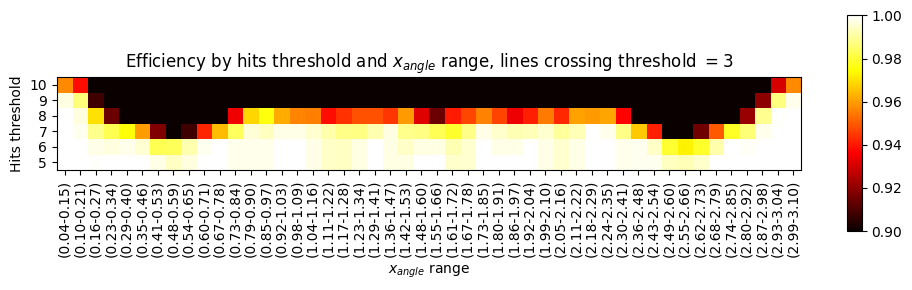

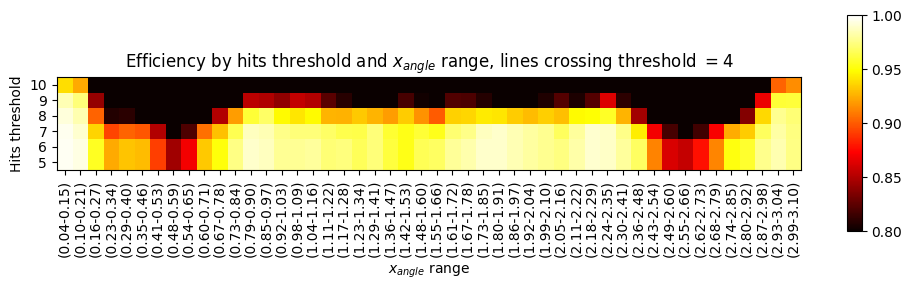

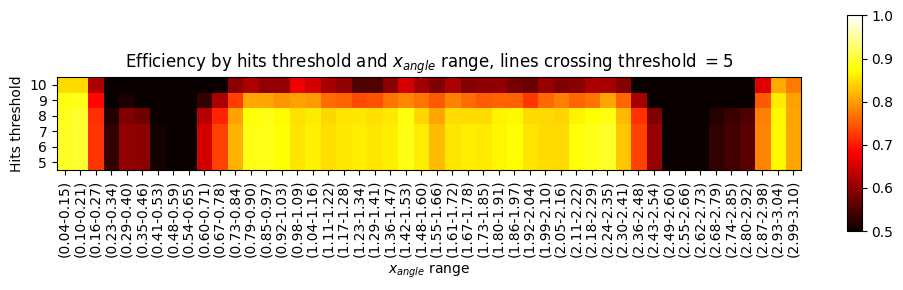

In [28]:
def draw_efficiency_heatmap_for_crossings_threshold(stats_by_thresholds, crossings_threshold, clim=None):
    treshold_range_pair_to_accuracy_map = {}
    for threshold in range(5, 11):
        for i, accuracy in enumerate(stats_by_thresholds[(crossings_threshold, threshold)]["x_angle_accuracies_all"]):
            x_angle_range = stats_by_thresholds[(crossings_threshold, threshold)]["x_angle_bins_all"][i]
            treshold_range_pair_to_accuracy_map[(x_angle_range, threshold)] = accuracy

    def x_ticks_label_func(x_value):
        return f"({x_value[0]:.2f}-{x_value[1]:.2f})"
    draw_heat_map(treshold_range_pair_to_accuracy_map, stats_by_thresholds[(3, 5)]["x_angle_bins_all"], range(5, 11), "Efficiency by hits threshold and $x_{angle}$ range, lines crossing threshold $=" + str(crossings_threshold) + "$", "$x_{angle}$ range", "Hits threshold", figure_size=(12, 4), rotate_x_ticks=True, x_ticks_label_func=x_ticks_label_func, clim=clim, aspect=15, shrink=0.7)
        
draw_efficiency_heatmap_for_crossings_threshold(stats_by_thresholds, 3, clim=(0.9, 1))
draw_efficiency_heatmap_for_crossings_threshold(stats_by_thresholds, 4, clim=(0.8, 1))
draw_efficiency_heatmap_for_crossings_threshold(stats_by_thresholds, 5, clim=(0.5, 1))

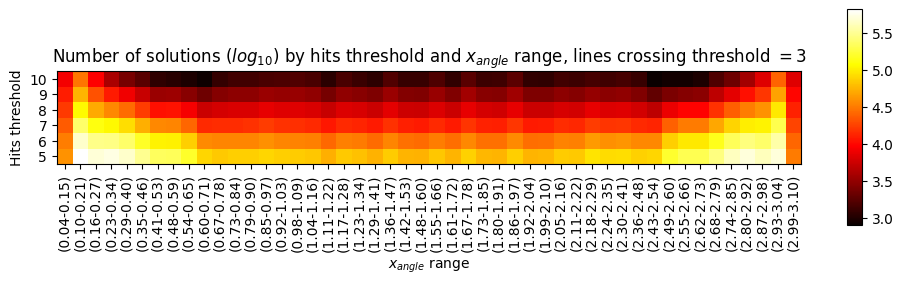

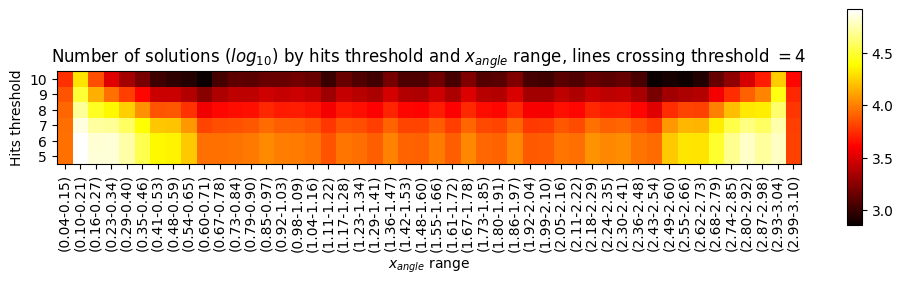

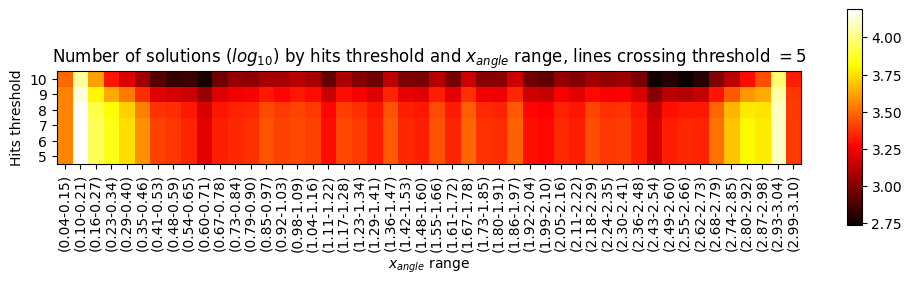

In [29]:
def draw_num_solutions_heatmap_for_crossings_threshold(stats_by_thresholds, crossings_threshold, clim=None):
    treshold_range_pair_to_num_solutions_map = {}
    for threshold in range(5, 11):
        for x_angle_range, num_solutions in stats_by_thresholds[(crossings_threshold, threshold)]["solutions_count_by_x_angle_range"].items():
            treshold_range_pair_to_num_solutions_map[(x_angle_range, threshold)] = num_solutions

    def x_ticks_label_func(x_value):
        return f"({x_value[0]:.2f}-{x_value[1]:.2f})"
    draw_heat_map(treshold_range_pair_to_num_solutions_map, stats_by_thresholds[(3, 5)]["solutions_count_by_x_angle_range"], range(5, 11), "Number of solutions ($log_{10}$) by hits threshold and $x_{angle}$ range, lines crossing threshold $=" + str(crossings_threshold) + "$", "$x_{angle}$ range", "Hits threshold", figure_size=(12, 4), rotate_x_ticks=True, x_ticks_label_func=x_ticks_label_func, log_scale=True, clim=clim, aspect=15, shrink=0.7)
        
draw_num_solutions_heatmap_for_crossings_threshold(stats_by_thresholds, 3)
draw_num_solutions_heatmap_for_crossings_threshold(stats_by_thresholds, 4)
draw_num_solutions_heatmap_for_crossings_threshold(stats_by_thresholds, 5)

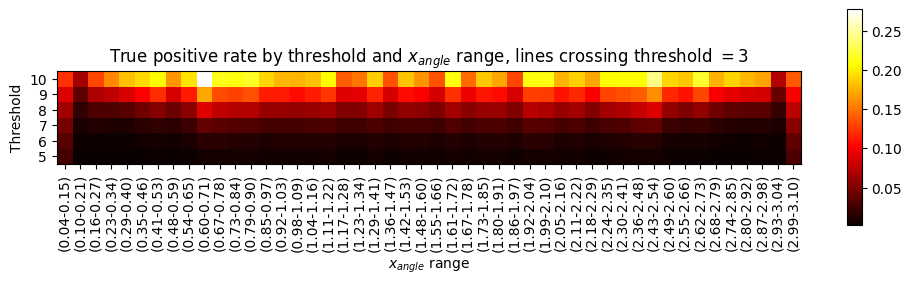

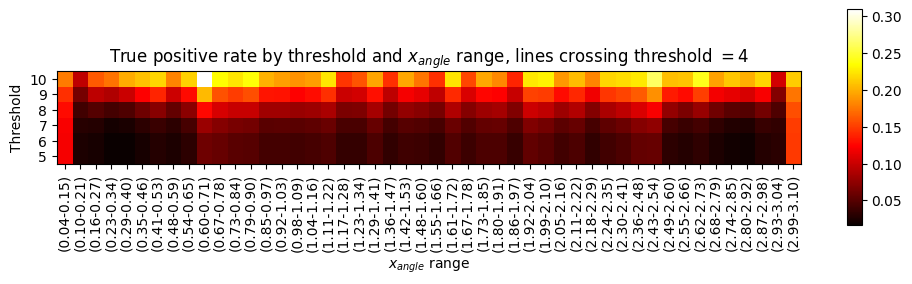

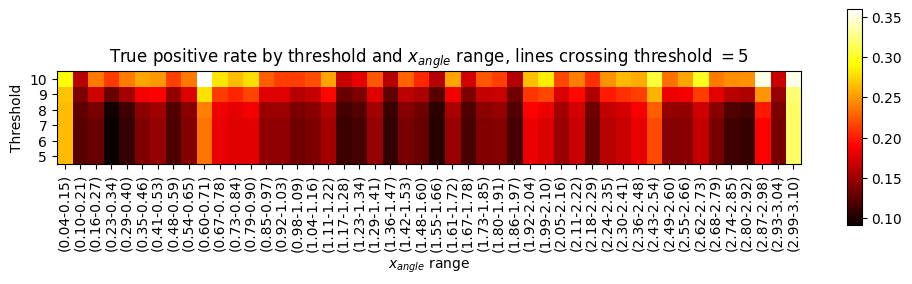

In [30]:
def draw_true_positive_rate_heatmap_for_threshold(stats_by_threshold, crossings_threshold, clim=None):
    treshold_range_pair_to_true_positive_rate_map = {}
    for threshold in range(5, 11):
        stats = stats_by_thresholds[(crossings_threshold, threshold)]
        for x_angle_range, num_solutions, index in zip(stats["solutions_count_by_x_angle_range"].keys(), stats["solutions_count_by_x_angle_range"].values(), range(len(stats["solutions_count_by_x_angle_range"]))):
            count = stats["x_angle_counts_all"][index]
            accuracy = stats["x_angle_accuracies_all"][index]

            if num_solutions == 0:
                treshold_range_pair_to_true_positive_rate_map[(x_angle_range, threshold)] = 0
            else:
                treshold_range_pair_to_true_positive_rate_map[(x_angle_range, threshold)] = min(1, count * accuracy / num_solutions)

    def x_ticks_label_func(x_value):
        return f"({x_value[0]:.2f}-{x_value[1]:.2f})"
    draw_heat_map(treshold_range_pair_to_true_positive_rate_map, stats_by_threshold[(3, 5)]["solutions_count_by_x_angle_range"], range(5, 11), "True positive rate by threshold and $x_{angle}$ range, lines crossing threshold $=" + str(crossings_threshold) + "$", "$x_{angle}$ range", "Threshold", figure_size=(12, 4), rotate_x_ticks=True, x_ticks_label_func=x_ticks_label_func, clim=clim, aspect=15, shrink=0.7)

draw_true_positive_rate_heatmap_for_threshold(stats_by_thresholds, 3)
draw_true_positive_rate_heatmap_for_threshold(stats_by_thresholds, 4)
draw_true_positive_rate_heatmap_for_threshold(stats_by_thresholds, 5)

# S accuracy by region for selected hits thresholds

In [8]:
erase_test_list()

In [9]:
test_params = copy.copy(generic_test_params)
test_params.testType = "SpacepointsSingleEvent"
test_params.numZRanges = 32
test_params.numXRanges = 48
test_params.multipleEventIds = list(range(20))
test_params.linesCrossingsThresholds = [4 for _ in range(test_params.numXRanges)]
test_params.hitsThresholds = [7 for _ in range(test_params.numXRanges)]
test_params.hitsThresholds[0] = 9
test_params.hitsThresholds[1] = 9
test_params.hitsThresholds[2] = 8
test_params.hitsThresholds[3] = 8
test_params.hitsThresholds[4] = 7

test_params.hitsThresholds[5:11] = [6 for _ in range(6)]
test_params.hitsThresholds[-12:-6] = [6 for _ in range(6)]

test_params.hitsThresholds[-5] = 7
test_params.hitsThresholds[-4] = 8
test_params.hitsThresholds[-3] = 8
test_params.hitsThresholds[-2] = 9
test_params.hitsThresholds[-1] = 9

test_params.outputResultsFile = base_dir + f"/quality_tests/s_accuracy_by_region/results_th7_crossings4.csv"
write_config(test_params, base_dir_relative + "/quality_tests/s_accuracy_by_region", base_dir_relative + f"/quality_tests/s_accuracy_by_region/config_th7_crossings4.json")
add_test_to_list(base_dir + f"/quality_tests/s_accuracy_by_region/config_th7_crossings4.json")

[1076, 2093, 1564, 1218, 1008, 877, 742, 664, 631, 587, 536, 488, 476, 458, 426, 414, 407, 357, 340, 330, 369, 363, 347, 324, 351, 386, 416, 386, 376, 396, 426, 398, 400, 407, 394, 438, 506, 537, 545, 632, 701, 753, 838, 1020, 1231, 1461, 1956, 979]
[1063, 2047, 1395, 1023, 903, 800, 660, 561, 549, 548, 510, 475, 470, 451, 416, 403, 396, 346, 328, 318, 359, 348, 331, 311, 335, 375, 406, 381, 372, 390, 418, 389, 387, 399, 390, 433, 496, 520, 497, 545, 593, 646, 736, 907, 1089, 1359, 1889, 940]
0.988 0.978 0.892 0.840 0.896 0.912 0.889 0.845 0.870 0.934 0.951 0.973 0.987 0.985 0.977 0.973 0.973 0.969 0.965 0.964 0.973 0.959 0.954 0.960 0.954 0.972 0.976 0.987 0.989 0.985 0.981 0.977 0.968 0.980 0.990 0.989 0.980 0.968 0.912 0.862 0.846 0.858 0.878 0.889 0.885 0.930 0.966 0.960 


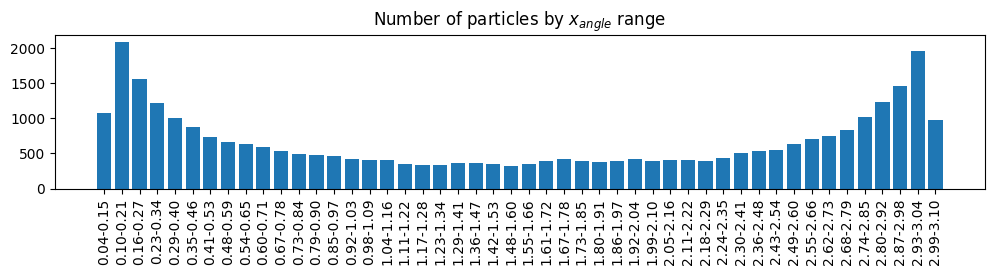

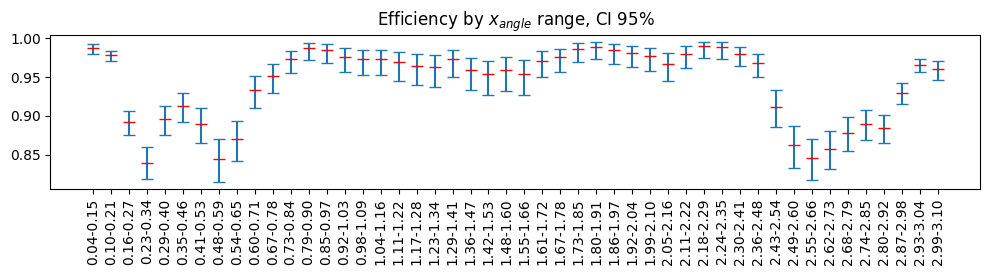

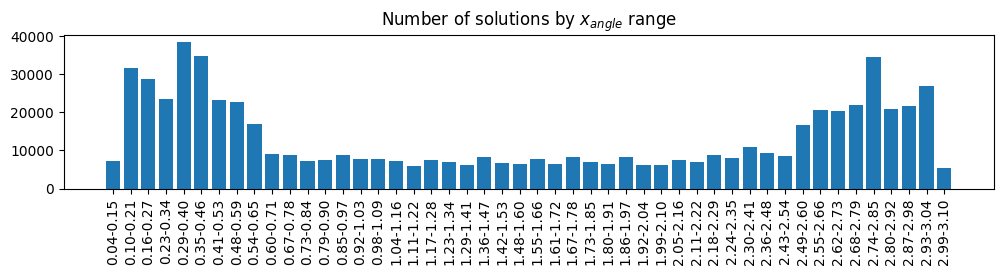

[14107, 2513, 683, 229, 92, 58, 35, 18, 17, 8, 4, 5, 5, 3, 2, 2, 6, 5, 7, 1, 0, 2, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0]
[13105, 2367, 643, 219, 83, 56, 35, 18, 17, 8, 4, 5, 5, 2, 2, 2, 6, 5, 7, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
0.929 0.942 0.941 0.956 0.902 0.966 1.000 1.000 1.000 1.000 1.000 1.000 1.000 0.667 1.000 1.000 1.000 1.000 1.000 1.000 0.000 1.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 


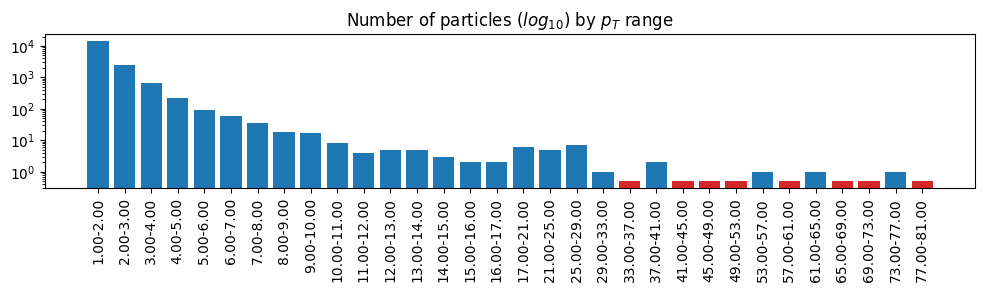

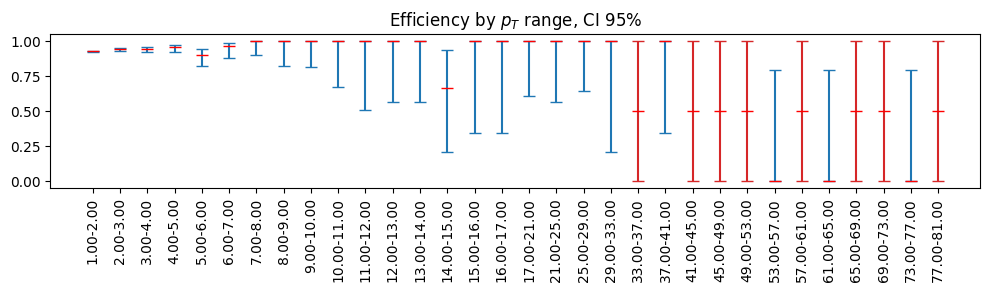

In [34]:
print(stats["x_angle_counts_all"])
print(stats["x_angle_sums_all"])
for i in range(len(stats["x_angle_accuracies_all"])):
    print(f"{stats['x_angle_accuracies_all'][i]:.3f}", end=" ")
print()

zero_count_mask = [stats["x_angle_counts_all"][i] == 0 for i in range(len(stats["x_angle_bins_all"]))]
draw_bar_chart(stats["x_angle_bins_all"], stats["x_angle_counts_all"], "Number of particles by $x_{angle}$ range", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask)
accuracy_data = [stats['x_angle_bins_all'], stats['x_angle_accuracies_all'], stats['x_angle_counts_all'], stats['x_angle_sums_all']]
draw_errorbar_chart(accuracy_data, "Efficiency by $x_{angle}$ range, CI 95%", figure_size=(12, 2), draw_values=False)
draw_bar_chart(list(stats["solutions_count_by_x_angle_range"].keys()), [stats["solutions_count_by_x_angle_range"][i] for i in stats["solutions_count_by_x_angle_range"].keys()], "Number of solutions by $x_{angle}$ range", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask, y_log=False)

print(stats["pt_counts_all"])
print(stats["pt_sums_all"])
for i in range(len(stats["pt_accuracies_all"])):
    print(f"{stats['pt_accuracies_all'][i]:.3f}", end=" ")
print()

zero_count_mask = [stats["pt_counts_all"][i] == 0 for i in range(len(stats["pt_bins_all"]))]
draw_bar_chart(stats["pt_bins_all"], stats["pt_counts_all"], "Number of particles ($log_{10}$) by $p_{T}$ range", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask, y_log=True)
accuracy_data = [stats['pt_bins_all'], stats['pt_accuracies_all'], stats['pt_counts_all'], stats['pt_sums_all']]
draw_errorbar_chart(accuracy_data, "Efficiency by $p_{T}$ range, CI 95%", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask)

# S accidentaly correct solutions by region for selected hits thresholds

In [ ]:
erase_test_list()

In [ ]:
test_params = copy.copy(generic_test_params)
test_params.testType = "SpacepointsSingleEvent"
test_params.numZRanges = 32
test_params.numXRanges = 48
test_params.multipleEventIds = list(range(20))
test_params.linesCrossingsThresholds = [4 for _ in range(test_params.numXRanges)]
test_params.hitsThresholds = [7 for _ in range(test_params.numXRanges)]
test_params.hitsThresholds[0] = 9
test_params.hitsThresholds[1] = 9
test_params.hitsThresholds[2] = 8
test_params.hitsThresholds[3] = 8
test_params.hitsThresholds[4] = 7

test_params.hitsThresholds[5:11] = [6 for _ in range(6)]
test_params.hitsThresholds[-12:-6] = [6 for _ in range(6)]

test_params.hitsThresholds[-5] = 7
test_params.hitsThresholds[-4] = 8
test_params.hitsThresholds[-3] = 8
test_params.hitsThresholds[-2] = 9
test_params.hitsThresholds[-1] = 9

test_params.outputResultsFile = base_dir + f"/quality_tests/s_correct_by_accident/results.csv"
write_config(test_params, base_dir_relative + "/quality_tests/s_correct_by_accident", base_dir_relative + f"/quality_tests/s_correct_by_accident/config.json")
add_test_to_list(base_dir + f"/quality_tests/s_correct_by_accident/config.json")

In [ ]:
solutions_all = Solution.read_from_csv(base_dir_relative + f"/quality_tests/s_correct_by_accident/results.csv")

for solution in solutions_all:
    solution.q = -solution.q

stats = get_stats_for_all_events(particles_initial, solutions_all, test_params)

In [ ]:
zero_count_mask = [stats["x_angle_counts_all"][i] == 0 for i in range(len(stats["x_angle_bins_all"]))]
accuracy_data = [stats['x_angle_bins_all'], stats['x_angle_accuracies_all'], stats['x_angle_counts_all'], stats['x_angle_sums_all']]
draw_errorbar_chart(accuracy_data, "Efficiency by $x_{angle}$ range, CI 95%", figure_size=(12, 2), draw_values=False, color_red=zero_count_mask)

# S accuracy correlations

In [35]:
erase_test_list()

In [36]:
test_params = copy.copy(generic_test_params)
test_params.testType = "SpacepointsSingleEvent"
test_params.numZRanges = 32
test_params.numXRanges = 48
test_params.multipleEventIds = list(range(20))
test_params.linesCrossingsThresholds = [4 for _ in range(test_params.numXRanges)]
test_params.hitsThresholds = [7 for _ in range(test_params.numXRanges)]
test_params.hitsThresholds[0] = 9
test_params.hitsThresholds[1] = 9
test_params.hitsThresholds[2] = 8
test_params.hitsThresholds[3] = 8
test_params.hitsThresholds[4] = 7

test_params.hitsThresholds[5:11] = [6 for _ in range(6)]
test_params.hitsThresholds[-12:-6] = [6 for _ in range(6)]

test_params.hitsThresholds[-5] = 7
test_params.hitsThresholds[-4] = 8
test_params.hitsThresholds[-3] = 8
test_params.hitsThresholds[-2] = 9
test_params.hitsThresholds[-1] = 9

test_params.outputResultsFile = base_dir + f"/quality_tests/s_accuracy_correlations/results.csv"
write_config(test_params, base_dir_relative + "/quality_tests/s_accuracy_correlations", base_dir_relative + f"/quality_tests/s_accuracy_correlations/config.json")
add_test_to_list(base_dir + f"/quality_tests/s_accuracy_correlations/config.json")

In [37]:
solutions_all = Solution.read_from_csv(base_dir_relative + f"/quality_tests/s_accuracy_correlations/results.csv")

particles_filtered_all = []
found_particles = []
not_found_particles = []

for event_id in range(20):
    particles_filtered = filter_particles_by_x_angle_event_id_pt_and_q(particles_initial, event_id, test_params.minXAngle, test_params.maxXAngle, min_pt=1)
    solutions = [s for s in solutions_all if s.event_id == event_id]
    
    particles_filtered_all.extend(particles_filtered)
    particle_to_solutions_map = map_solutions_to_particles_s(particles_filtered, solutions)
    for particle in particles_filtered:
        if particle.particle_id in particle_to_solutions_map:
            found_particles.append(particle)
        else:
            not_found_particles.append(particle)

In [38]:
print(len(particles_initial))
print(len(particles_filtered_all))
print(len(found_particles))
print(len(not_found_particles))

86766
16873
15711
1162


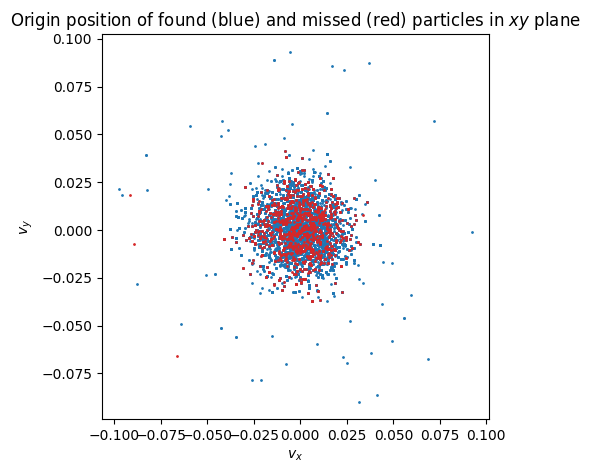

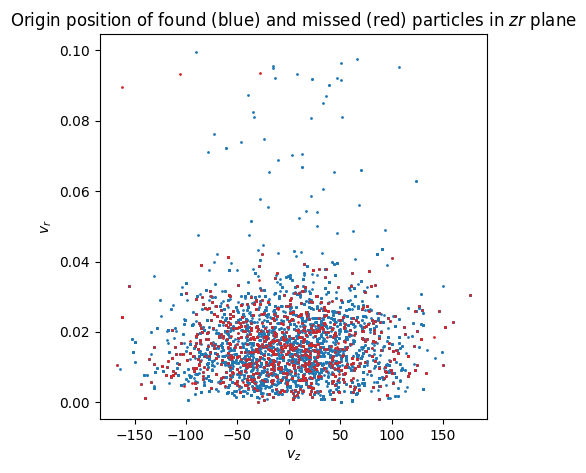

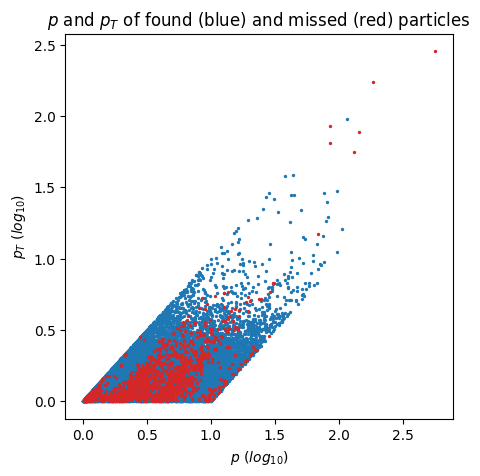

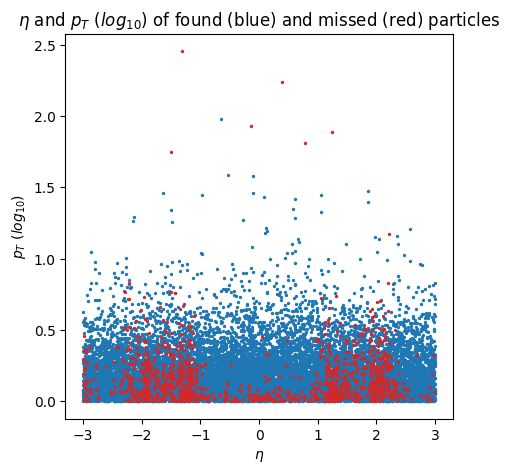

In [54]:
found_vx = [p.vx for p in found_particles]
found_vy = [p.vy for p in found_particles]
not_found_vx = [p.vx for p in not_found_particles]
not_found_vy = [p.vy for p in not_found_particles]

plt.figure(figsize=(5, 5))
plt.scatter(found_vx, found_vy, color="tab:blue", s=1)
plt.scatter(not_found_vx, not_found_vy, color="tab:red", s=1)
plt.xlabel("$v_{x}$")
plt.ylabel("$v_{y}$")
plt.title("Origin position of found (blue) and missed (red) particles in $xy$ plane")
plt.show()


found_vz = [p.vz for p in found_particles]
found_vr = [math.sqrt(p.vx ** 2 + p.vy ** 2) for p in found_particles]
not_found_vz = [p.vz for p in not_found_particles]
not_found_vr = [math.sqrt(p.vx ** 2 + p.vy ** 2) for p in not_found_particles]

plt.figure(figsize=(5, 5))
plt.scatter(found_vz, found_vr, color="tab:blue", s=1)
plt.scatter(not_found_vz, not_found_vr, color="tab:red", s=1)
plt.xlabel("$v_{z}$")
plt.ylabel("$v_{r}$")
plt.title("Origin position of found (blue) and missed (red) particles in $zr$ plane")
plt.show()
plt.close()


found_p = [math.log10(p.p) for p in found_particles]
found_pt = [math.log10(p.pt) for p in found_particles]
not_found_p = [math.log10(p.p) for p in not_found_particles]
not_found_pt = [math.log10(p.pt) for p in not_found_particles]

plt.figure(figsize=(5, 5))
plt.scatter(found_p, found_pt, color="tab:blue", s=2)
plt.scatter(not_found_p, not_found_pt, color="tab:red", s=2)
plt.xlabel("$p$ ($log_{10}$)")
plt.ylabel("$p_{T}$ ($log_{10}$)")
plt.title("$p$ and $p_{T}$ of found (blue) and missed (red) particles")
plt.show()


found_eta = [p.eta for p in found_particles]
not_found_eta = [p.eta for p in not_found_particles]

plt.figure(figsize=(5, 5))
plt.scatter(found_eta, found_pt, color="tab:blue", s=2)
plt.scatter(not_found_eta, not_found_pt, color="tab:red", s=2)
plt.xlabel("$\eta$")
plt.ylabel("$p_{T}$ ($log_{10}$)")
plt.title("$\eta$ and $p_{T}$ ($log_{10}$) of found (blue) and missed (red) particles")
plt.show()